In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data structure overview:
  Model          Task Metric     Value
0   ANN  all_voltages    MAE  0.277513
1   ANN  all_voltages    MSE  0.124947
2   ANN  all_voltages   RMSE  0.353478
3   ANN  all_voltages     R2  0.875564
4   ANN  all_voltages  NRMSE  0.058305


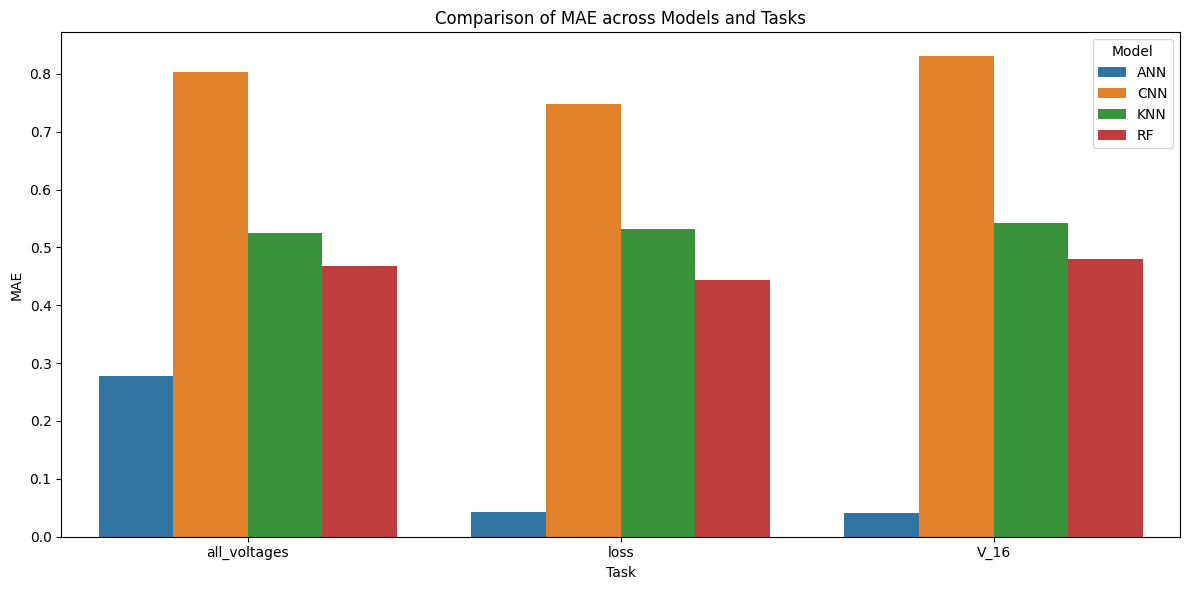

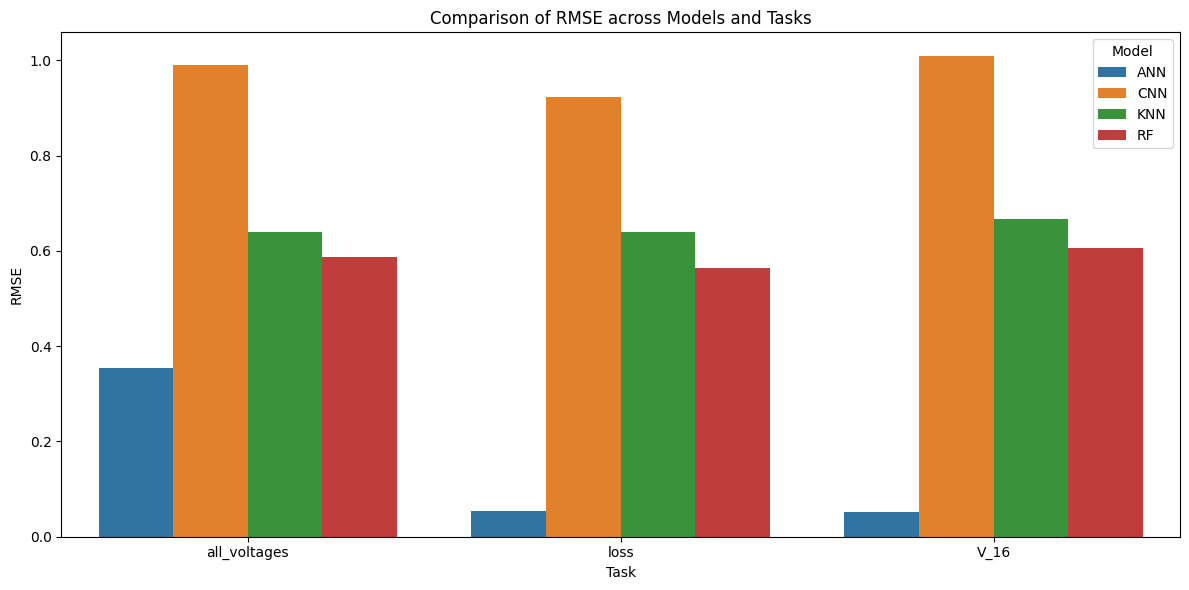

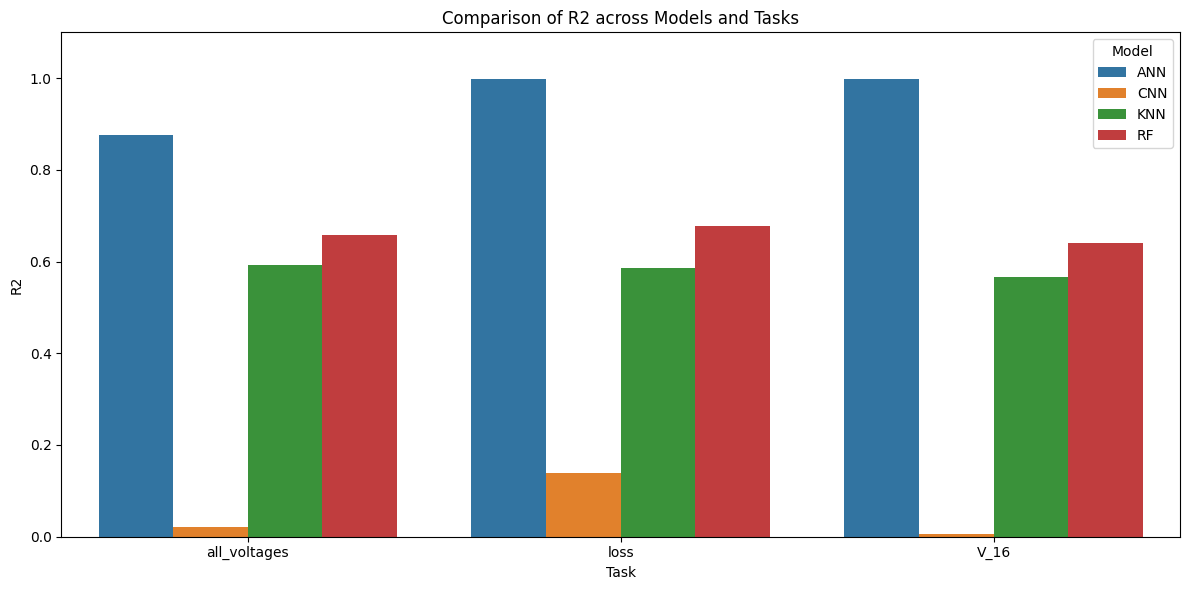

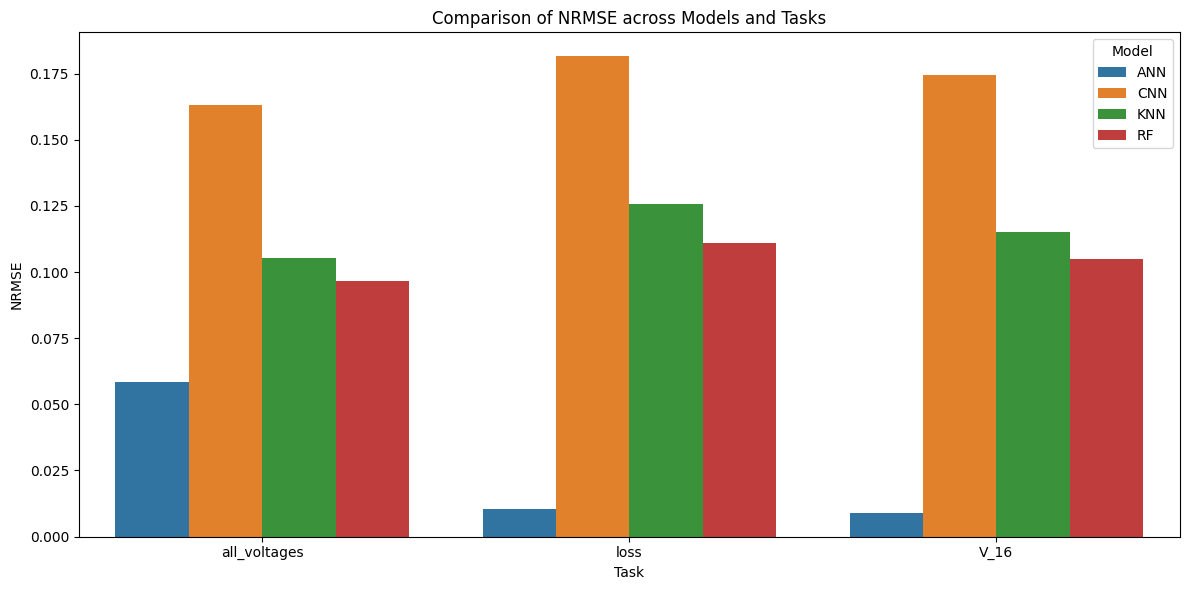

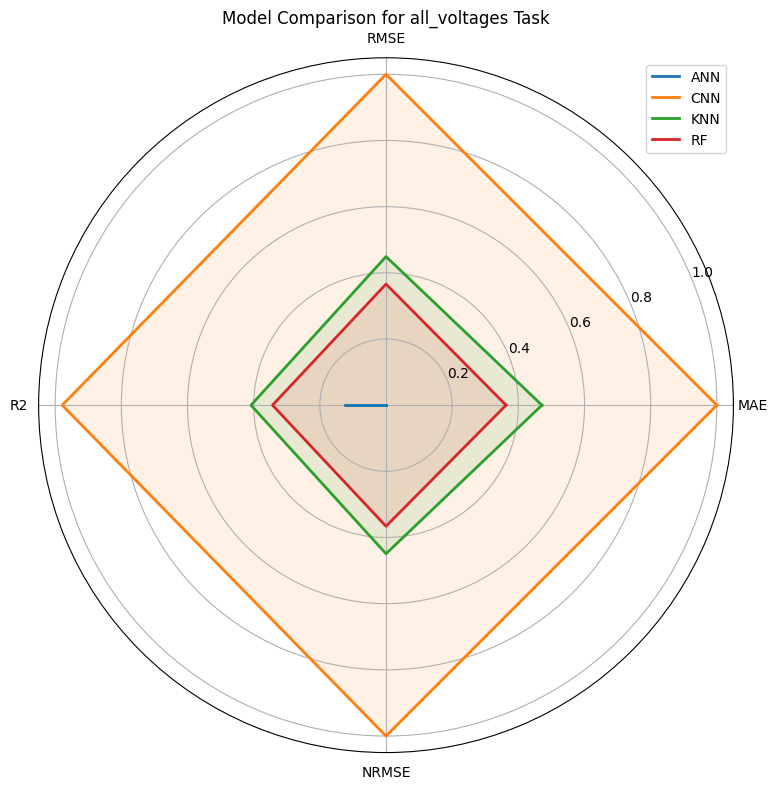

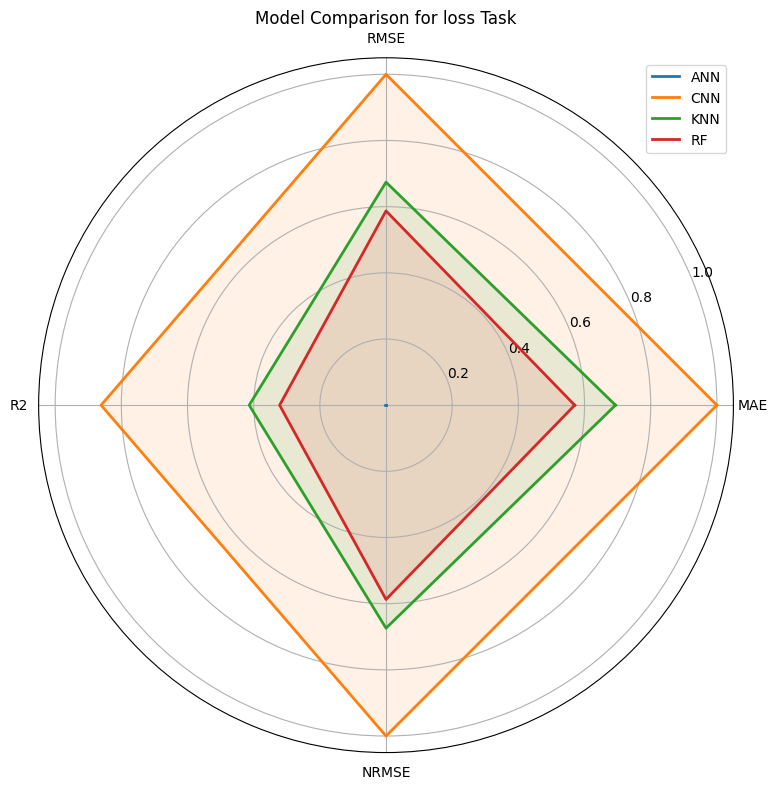

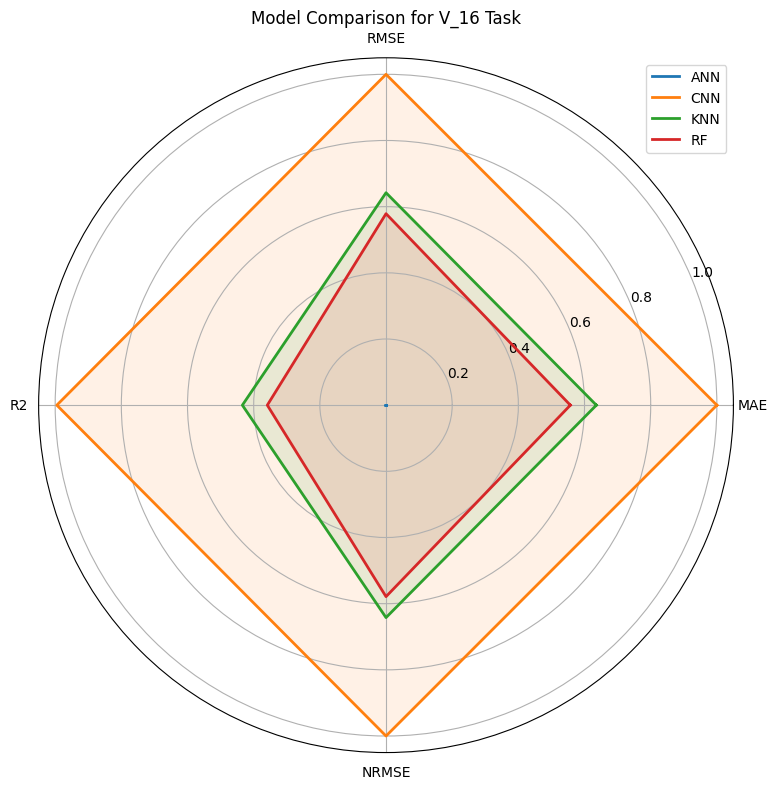


Best Model Summary:
            Task Metric Best Model     Value
0   all_voltages    MAE        ANN  0.277513
1   all_voltages   RMSE        ANN  0.353478
2   all_voltages     R2        ANN  0.875564
3   all_voltages  NRMSE        ANN  0.058305
4           loss    MAE        ANN  0.041880
5           loss   RMSE        ANN  0.053354
6           loss     R2        ANN  0.997119
7           loss  NRMSE        ANN  0.010499
8           V_16    MAE        ANN  0.040474
9           V_16   RMSE        ANN  0.052174
10          V_16     R2        ANN  0.997337
11          V_16  NRMSE        ANN  0.009030

Overall Model Performance (averaged across tasks):
      R2_Mean  Error_Mean
ANN  0.956673    0.099634
CNN  0.055001    0.646677
KNN  0.581390    0.432201
RF   0.658834    0.384524

Detailed Performance Analysis:

--- all_voltages Task ---
MAE: Best = ANN (0.2775), Worst = CNN (0.8027)
RMSE: Best = ANN (0.3535), Worst = CNN (0.9898)
R2: Best = ANN (0.8756), Worst = CNN (0.0213)
NRMSE: Best 

In [5]:
# Define models and tasks
models = ['ann', 'cnn', 'knn', 'rf']
tasks = ['all_voltages', 'loss', 'V_16']
metrics = ['MAE', 'MSE', 'RMSE', 'R2', 'NRMSE', 'MAPE', 'Max Error']

# Create a dictionary to store all results
results = {}

# Read all CSV files and organize them
for model in models:
    for task in tasks:
        filename = f"./results/{model}_{task}_metrics.csv"
        try:
            df = pd.read_csv(filename)
            # Extract the key metrics
            results[(model, task)] = {
                metric: df.loc[df['Metric'] == metric, 'Best Test'].values[0] 
                for metric in metrics if metric in df['Metric'].values
            }
        except FileNotFoundError:
            print(f"Warning: File {filename} not found")
            continue

# Convert results to a structured DataFrame for easier analysis
result_rows = []
for (model, task), metrics_values in results.items():
    for metric, value in metrics_values.items():
        result_rows.append({
            'Model': model.upper(),
            'Task': task,
            'Metric': metric,
            'Value': value
        })

result_df = pd.DataFrame(result_rows)

# Function to plot comparison of metrics across models and tasks
def plot_metric_comparison(metric_name):
    plt.figure(figsize=(12, 6))
    
    # Filter for the specific metric
    metric_data = result_df[result_df['Metric'] == metric_name]
    
    # Create the grouped bar chart
    ax = sns.barplot(x='Task', y='Value', hue='Model', data=metric_data)
    
    plt.title(f'Comparison of {metric_name} across Models and Tasks')
    plt.xlabel('Task')
    plt.ylabel(metric_name)
    plt.xticks(rotation=0)
    plt.legend(title='Model')
    
    # Adjust y-axis limits if needed (especially for R2)
    if metric_name == 'R2':
        plt.ylim(0, 1.1)
    
    plt.tight_layout()
    plt.show()

# Create a radar chart for comparing models across metrics for each task
def plot_radar_chart(task_name):
    # Filter data for the specific task
    task_data = result_df[result_df['Task'] == task_name]
    
    # Prepare data for radar chart
    models_list = task_data['Model'].unique()
    metrics_list = ['MAE', 'RMSE', 'R2', 'NRMSE']  # Using only these metrics for clarity
    
    # Create figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, polar=True)
    
    # Set the angles for each metric
    angles = np.linspace(0, 2*np.pi, len(metrics_list), endpoint=False).tolist()
    angles += angles[:1]  # Close the circle
    
    # Set the labels for each angle
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_list)
    
    # For each model, plot the values
    for model in models_list:
        model_data = task_data[task_data['Model'] == model]
        values = []
        
        for metric in metrics_list:
            val = model_data[model_data['Metric'] == metric]['Value'].values[0]
            
            # Normalize values for better visualization
            if metric == 'R2':
                # R2 closer to 1 is better, so we invert it to match other metrics
                values.append(1 - val)  # Lower is better
            else:
                # Normalize other metrics to [0,1] range within the dataset
                metric_min = task_data[task_data['Metric'] == metric]['Value'].min()
                metric_max = task_data[task_data['Metric'] == metric]['Value'].max()
                
                if metric_max == metric_min:
                    values.append(0)  # Handle edge case
                else:
                    values.append((val - metric_min) / (metric_max - metric_min))
        
        # Close the loop
        values += values[:1]
        
        # Plot the model
        ax.plot(angles, values, linewidth=2, label=model)
        ax.fill(angles, values, alpha=0.1)
    
    ax.set_title(f'Model Comparison for {task_name} Task')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Generate a summary table of best models for each task and metric
def generate_summary_table():
    summary_rows = []
    
    for task in tasks:
        for metric in ['MAE', 'RMSE', 'R2', 'NRMSE']:
            task_metric_data = result_df[(result_df['Task'] == task) & (result_df['Metric'] == metric)]
            
            if metric == 'R2':
                # For R2, higher is better
                best_idx = task_metric_data['Value'].idxmax()
            else:
                # For other metrics, lower is better
                best_idx = task_metric_data['Value'].idxmin()
            
            best_model = task_metric_data.loc[best_idx, 'Model']
            best_value = task_metric_data.loc[best_idx, 'Value']
            
            summary_rows.append({
                'Task': task,
                'Metric': metric,
                'Best Model': best_model,
                'Value': best_value
            })
    
    summary_df = pd.DataFrame(summary_rows)
    return summary_df

# View the structure of the results
print("Data structure overview:")
print(result_df.head())

# Generate comparison plots for key metrics
for metric in ['MAE', 'RMSE', 'R2', 'NRMSE']:
    plot_metric_comparison(metric)

# Generate radar charts for each task
for task in tasks:
    plot_radar_chart(task)

# Generate and display summary table
summary_table = generate_summary_table()
print("\nBest Model Summary:")
print(summary_table)

# Additional analysis: Calculate overall model performance score
# Lower score is better (except for R2 which we handle separately)
model_scores = {}
for model in models:
    r2_score = result_df[(result_df['Model'] == model.upper()) & (result_df['Metric'] == 'R2')]['Value'].mean()
    error_score = result_df[(result_df['Model'] == model.upper()) & 
                           (result_df['Metric'].isin(['MAE', 'RMSE', 'NRMSE']))]['Value'].mean()
    
    # Combined score: we want high R2 and low error metrics
    model_scores[model.upper()] = {'R2_Mean': r2_score, 'Error_Mean': error_score}

model_scores_df = pd.DataFrame.from_dict(model_scores, orient='index')
print("\nOverall Model Performance (averaged across tasks):")
print(model_scores_df)

# Print detailed insights
print("\nDetailed Performance Analysis:")
for task in tasks:
    print(f"\n--- {task} Task ---")
    for metric in ['MAE', 'RMSE', 'R2', 'NRMSE']:
        task_metric_data = result_df[(result_df['Task'] == task) & (result_df['Metric'] == metric)]
        if metric == 'R2':
            best_idx = task_metric_data['Value'].idxmax()
            worst_idx = task_metric_data['Value'].idxmin()
        else:
            best_idx = task_metric_data['Value'].idxmin()
            worst_idx = task_metric_data['Value'].idxmax()
            
        best_model = task_metric_data.loc[best_idx, 'Model']
        best_value = task_metric_data.loc[best_idx, 'Value']
        worst_model = task_metric_data.loc[worst_idx, 'Model']
        worst_value = task_metric_data.loc[worst_idx, 'Value']
        
        print(f"{metric}: Best = {best_model} ({best_value:.4f}), Worst = {worst_model} ({worst_value:.4f})")